In [39]:
import os, sys
project_root = os.path.abspath("..")
sys.path.insert(0, project_root) # set up the working directory

In [40]:
from pathlib import Path
import joblib

from joblib import Parallel, delayed, load
import numpy as np
import shap


import pandas as pd

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt

from src.models.monthly_model.monthly_climademic_model import ClimademicMonthlyModel
from src.data_pipeline.worldwide.build_global_dataset import load_global_dataset
from functools import partial
import kmedoids
from sklearn.metrics.pairwise import euclidean_distances

In [41]:
def load_model(specie, year):
    model = ClimademicMonthlyModel()
    model_name = f"{specie}/{year}_ocsvm_{specie}_quantile_75.model'"
    model_path = Path(config["paths"]["models_directory"], model_name)
    model.load(model_path)
    return model

In [42]:
def get_locations_sample(config, specie, year_analysis, model_year, locations_gdf, months):

    _columns_clima = ['t2m', 'd2m', 'tp', 'si10']
    _columns_lulc_pop = ['pop_density', 'Ocean', 'Urban',
                'Cropland', 'Pasture', 'Forest', 'Shrub',
                'Barren', 'Water']

    #load global dataset for the year=year_analysis and convert it to geopandas dataframe
    features_global_ds = load_global_dataset(config, year_analysis)
    features_global_ds['geometry'] = features_global_ds['geometry'].apply(wkt.loads)
    features_global_gdf = gpd.GeoDataFrame(features_global_ds, geometry='geometry')
    features_global_gdf.crs = 'epsg:4326' 

    #select only features corresponding to locations
    features_locations = gpd.sjoin(locations_gdf, features_global_gdf, how="inner", predicate="within").drop(columns=["index_right"]).rename(columns={
                                                            "longitude_left": "lon_location",
                                                            "latitude_left": "lat_location",
                                                            "longitude_right": "longitude",
                                                            "latitude_right": "latitude",
                                                        })

    location_samples_monthly = []
    for month in months:
        cols = [feat + f"_{month}" for feat in _columns_clima] + _columns_lulc_pop
        X_sample = features_locations[cols].copy()

        X_sample = X_sample.rename(
            columns={
                f"{feat}_{month}": f"{feat}_q_0.75"
                for feat in _columns_clima
            })

        location_samples_monthly.append(X_sample)
    X_locations = pd.concat([x for x in location_samples_monthly])
    return X_locations 

In [43]:
def get_location_probabilities(config, specie, year_analysis, model_year, locations_gdf,  months):
    results = []
    for month in months:
        monthly_fpath_dir = Path(config["paths"]["predictions"], f"{specie}", f"{year_analysis}")
        monthly_result_filename=str(year_analysis)+'_monthly_mean_'+str(month)+'_ocsvm_'+specie+'_predictions_'+str(model_year)+'_mod.csv'
        monthly_fpath = Path(monthly_fpath_dir, monthly_result_filename)

        prob_df = pd.read_csv(monthly_fpath, usecols=["longitude", "latitude", "geometry", "Prob_1"])

        prob_df['geometry'] = prob_df['geometry'].apply(wkt.loads)
        prob_gdf = gpd.GeoDataFrame(prob_df, geometry='geometry')
        prob_gdf.crs = 'epsg:4326'

        result = gpd.sjoin(locations_gdf, prob_gdf, how="inner", predicate="within")
        result["Month"] = month      # keep track of the month
        results.append(result)



    loc_probabilities = pd.concat(results, ignore_index=True).drop(columns=["index_right"]).rename(columns={
                                                                "longitude_left": "lon_location",
                                                                "latitude_left": "lat_location",
                                                                "longitude_right": "longitude",
                                                                "latitude_right": "latitude",
                                                            })
    return loc_probabilities

In [44]:
def load_training_data(config, specie, year, use_cols=None):
    training_fname = f"{year}_{specie}_intermediate_training_ds.csv"
    training_fpath = Path(config["paths"]["models_directory"], f"{specie}/intermediate_training_data", training_fname)
    traing_ds = pd.read_csv(training_fpath, usecols=use_cols)
    return traing_ds

Load the config file

In [45]:
from config import load_config
config = load_config()

Pre-set / load all necessary variables

In [46]:
year_analysis = 2024
model_year = 2023
specie = "aegypti"

#load the scaler 
scaler_path = Path(config["paths"]["models_directory"], f"{specie}/scaler")
scaler = load(scaler_path)

model = load_model(specie, model_year)

In [47]:
columns_list=['t2m_q_0.75', 'd2m_q_0.75', 'tp_q_0.75', 'si10_q_0.75',
               'pop_density', 'Ocean', 'Urban',
               'Cropland', 'Pasture', 'Forest', 'Shrub',
               'Barren', 'Water']

Select the background dataset for SHAP analysis

In [48]:
X_background = load_training_data(config, specie, model_year, use_cols=columns_list)
#X_background_scaled = pd.DataFrame(scaler.transform(X_background), columns=X_background.columns)
X_background_scaled = scaler.transform(X_background)
km = kmedoids.KMedoids(n_clusters=100, method='fasterpam')
diss = euclidean_distances(X_background_scaled)
fp = kmedoids.fasterpam(diss, 100)
background = X_background_scaled[fp.medoids]

Locations for explanation:

In [49]:
locations_df = pd.DataFrame({
    "longitude": [13.41, 120.98, 13.18, 22.785, 90.39, -46.62, -80.19, 46.72, 100.52, 75.79],
    "latitude":  [52.52, 14.59,  32.88, 5.52,   23.78, -23.53,  25.77, 24.68, 13.74, 26.92],
    "Name": ["Berlin", "Manila", "Tripoli", "Tamanrasset", "Dhaka", "Sao Paulo", "Miami", "Riyadh", "Bangkok", "Jaipur"]
})

locations_gdf = gpd.GeoDataFrame(
    locations_df.copy(),
    geometry=gpd.points_from_xy(locations_df["longitude"], locations_df["latitude"]),
    crs="EPSG:4326") 

In [50]:
months = range(2, 13, 3)
explain_locations = get_locations_sample(config, specie, year_analysis, model_year, locations_gdf,months)
explain_locations_scaled = scaler.transform(explain_locations)

In [51]:
def shap_predict_function(model, X):
    """
    Function passed to KernelExplainer.

    KernelSHAP supplies NumPy arrays, so this function must return
    a one-dimensional numeric array with one output per row.
    """
    X = np.asarray(X, dtype=float)

    _, _ , scores = model.predict(X, probability=False)

    return np.asarray(scores, dtype=float).reshape(-1)

In [52]:
def explain_chunk (X_chunk, background, model):
    # Each thread gets its own mutable KernelExplainer state
    predict_fn = partial(shap_predict_function, model)
    local_explainer = shap.KernelExplainer(predict_fn, background)
    return local_explainer.shap_values(X_chunk, nsamples="auto")

In [15]:
n_jobs = 8
n_chunks = min(n_jobs, len(explain_locations_scaled))

# Preserve DataFrame columns/index where applicable
chunks = np.array_split(explain_locations_scaled, n_chunks)

results = Parallel(
    n_jobs=n_jobs,
    backend="threading"
)(
    delayed(explain_chunk)(chunk, background, model)
    for chunk in chunks
)

shap_values_locations = np.concatenate(results, axis=0)


shap_values_locations = np.asarray(
    shap_values_locations,
    dtype=float
)


# Normalize possible SHAP output dimensions
if (
    shap_values_locations.ndim == 3
    and shap_values_locations.shape[-1] == 1
):
    shap_values_locations = shap_values_locations[:, :, 0]


if shap_values_locations.shape != explain_locations_scaled.shape:
    raise ValueError(
        f"Unexpected SHAP shape {shap_values_locations.shape}; "
        f"expected {explain_locations_scaled.shape}."
    )

np.save(f"{specie}_shap_values_locations.npy", shap_values_locations)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [53]:
shap_values_locations = np.load(f"{specie}_shap_values_locations.npy")
feature_names = ["Temperature", "dewpoint Temperature", 'Total precipitation', 'Wind speed',
               "Population density", 'Ocean', 'Urban',
               'Cropland', 'Pasture', 'Forest', 'Shrub',
               'Barren', 'Water']
locations_probabilities = get_location_probabilities(config, specie, year_analysis, model_year, locations_gdf,  months)

In [54]:
print(locations_probabilities.shape)

(40, 8)


0.52.0


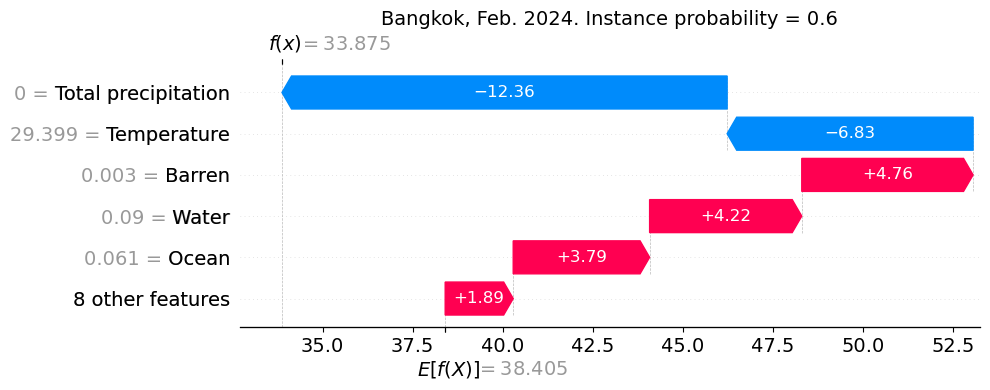

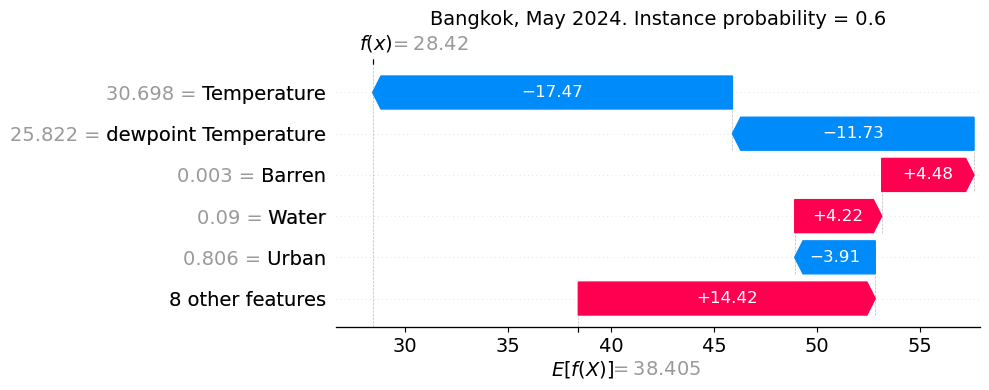

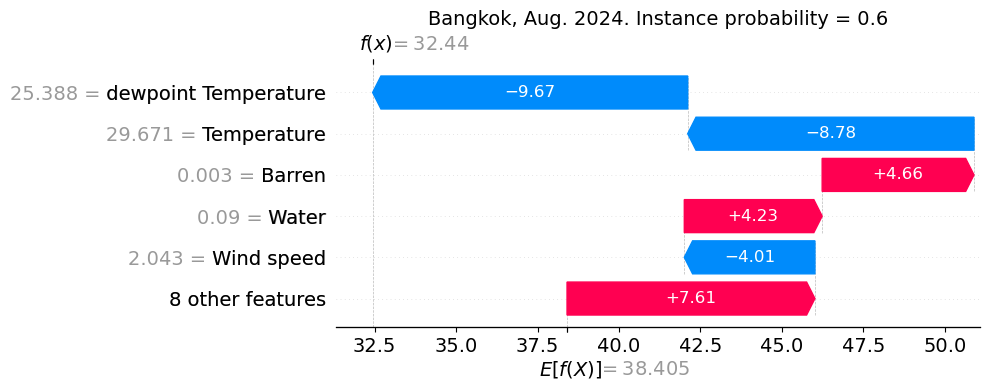

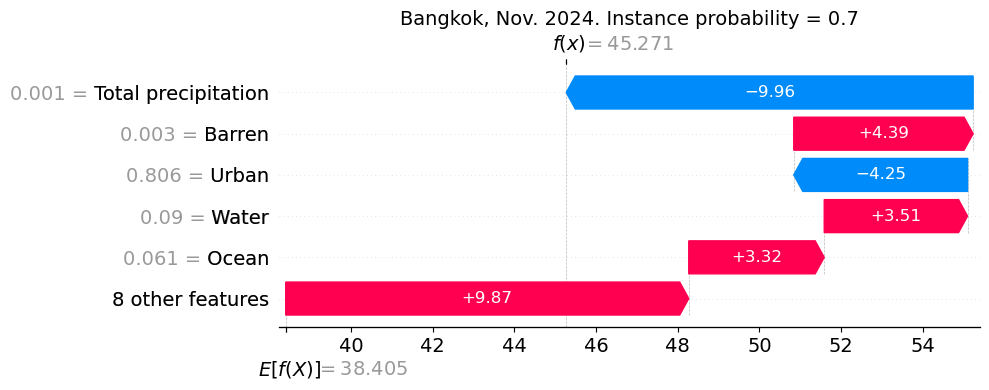

In [55]:
X_values = scaler.inverse_transform(explain_locations_scaled)
X_values[:, 0] = X_values[:, 0] - 273.15
X_values[:, 1] = X_values[:, 1] - 273.15

predict_fn = partial(shap_predict_function, model)
explainer = shap.KernelExplainer(predict_fn, background)

base_value = np.asarray(explainer.expected_value).squeeze()

shap_explanation_locations = shap.Explanation(
    values=np.asarray(shap_values_locations),
    base_values=np.full(len(X_values), base_value),
    data=X_values,
    feature_names=feature_names,
)
months_names = {2: "Feb.",
                5: "May",
                8: "Aug.",
                11: "Nov."}

loc_name = "Bangkok"
location = locations_probabilities.loc[locations_probabilities["Name"]== loc_name].copy()
print(shap.__version__)

for (idx, row) in  location.iterrows():
    shap.plots.waterfall(
        shap_explanation_locations[idx],
        max_display=6,
        show=False,
    )
    fig = plt.gcf()
    fig.set_size_inches(10, 4) 
    # The first axis normally contains the main waterfall plot
    main_ax = fig.axes[0]

    main_ax.set_title(
        f"{loc_name}, {months_names[row['Month']]} 2024. "
        f"Instance probability = {row['Prob_1']:.1f}",
        fontsize=14
    )

    # Apply font sizes to every axis created by SHAP
    for ax in fig.axes:
        ax.tick_params(axis="y", labelsize=10)
        ax.tick_params(axis="x", labelsize=10)

        for label in ax.get_yticklabels():
            label.set_fontsize(14)
        for label in ax.get_xticklabels():
                    label.set_fontsize(14)
        for text in ax.texts:
            if "f(x)" in text.get_text():
                x, y = text.get_position()
                text.set_position((x - 0.15, y))
                text.set_ha("right")

    plt.tight_layout()
    plt.show()
    #plt.close(fig)
